# Домашная работа #3
### Подготовил: Липатов Данила МСМТ243

## Задача 1. Оптимизация модулярности

распишем через md формат


Граф-цикл $C_N$: $N$ вершин, каждая степени $k_i = 2$, итого $m = N$ рёбер.

Разбиение: $k$ сообществ по $n = N/k$ вершин — последовательные участки цикла.

### Формула модулярности

$$Q = \frac{1}{2m} \sum_{i,j} \left[ A_{ij} - \frac{k_i k_j}{2m} \right] \delta(c_i, c_j)$$

Эквивалентная форма через суммирование по сообществам:

$$Q = \sum_c \left[ \frac{e_c}{m} - \left(\frac{d_c}{2m}\right)^2 \right]$$

где $e_c$ — число рёбер внутри сообщества $c$, $d_c = \sum_{i \in c} k_i$ — суммарная степень вершин сообщества.

Каждое сообщество — путь из $n$ вершин на цикле. Два крайних узла имеют по одному ребру наружу, поэтому:

$$e_c = n - 1$$

Суммарная степень вершин сообщества (все степени равны 2):

$$d_c = 2n$$

### Подставим в формулу

Учитывая $m = N$ и $k = N/n$ сообществ:

$$Q = k \left[ \frac{n-1}{N} - \left(\frac{2n}{2N}\right)^2 \right] = \frac{N}{n} \left[ \frac{n-1}{N} - \frac{n^2}{N^2} \right]$$

$${Q(n) = 1 - \frac{1}{n} - \frac{n}{N}}$$

### Нахождение оптимального $n$

Берём производную по $n$ и приравниваем к нулю:

$$\frac{dQ}{dn} = \frac{1}{n^2} - \frac{1}{N} = 0$$

$$n^* = \sqrt{N}, \qquad k^* = \frac{N}{n^*} = \sqrt{N}$$

Максимальная модулярность:

$$Q^* = Q(n^*) = 1 - \frac{1}{\sqrt{N}} - \frac{\sqrt{N}}{N} = 1 - \frac{2}{\sqrt{N}}$$

Сделаем мини проверку на максимум производной

$$\frac{d^2Q}{dn^2} = -\frac{2}{n^3} < 0 \quad $$

### Итог, что имеем

| Величина | Значение |
|---|---|
| Оптимальный размер кластера | $n^* = \sqrt{N}$ |
| Оптимальное число кластеров | $k^* = \sqrt{N}$ |
| Максимальная модулярность | $Q^* = 1 - \dfrac{2}{\sqrt{N}}$ |


Прогоним через псевдокод для проверки

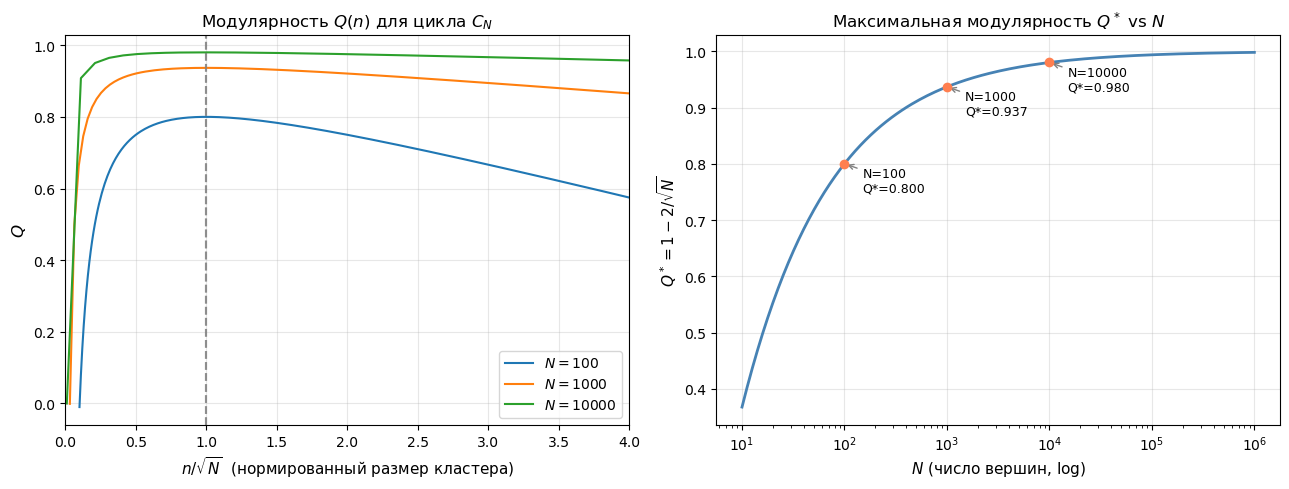

         N |    n* = √N |    k* = √N |         Q*
------------------------------------------------
       100 |       10.0 |       10.0 |     0.8000
      1000 |       31.6 |       31.6 |     0.9368
     10000 |      100.0 |      100.0 |     0.9800
    100000 |      316.2 |      316.2 |     0.9937


In [2]:
import numpy as np
import matplotlib.pyplot as plt

N_values = [100, 1000, 10000]
n_range = np.linspace(1, 100, 500)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for N in N_values:
    n = np.linspace(1, N, 1000)
    Q = 1 - 1/n - n/N
    axes[0].plot(n / np.sqrt(N), Q, label=f'$N={N}$')
    n_opt = np.sqrt(N)
    Q_opt = 1 - 2/np.sqrt(N)
    axes[0].axvline(x=1.0, color='gray', linestyle='--', alpha=0.5)

axes[0].set_xlabel(r'$n / \sqrt{N}$  (нормированный размер кластера)', fontsize=11)
axes[0].set_ylabel(r'$Q$', fontsize=12)
axes[0].set_title(r'Модулярность $Q(n)$ для цикла $C_N$', fontsize=12)
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_xlim(0, 4)

N_arr = np.logspace(1, 6, 200)
Q_opt = 1 - 2 / np.sqrt(N_arr)
axes[1].semilogx(N_arr, Q_opt, color='steelblue', linewidth=2)
axes[1].set_xlabel(r'$N$ (число вершин, log)', fontsize=11)
axes[1].set_ylabel(r'$Q^* = 1 - 2/\sqrt{N}$', fontsize=11)
axes[1].set_title(r'Максимальная модулярность $Q^*$ vs $N$', fontsize=12)
axes[1].grid(alpha=0.3)

for N in N_values:
    q = 1 - 2/np.sqrt(N)
    axes[1].plot(N, q, 'o', color='coral', zorder=5)
    axes[1].annotate(f'N={N}\nQ*={q:.3f}', xy=(N, q),
                     xytext=(N*1.5, q-0.05), fontsize=9,
                     arrowprops=dict(arrowstyle='->', color='gray'))

plt.tight_layout()
plt.show()

print(f"{'N':>10} | {'n* = √N':>10} | {'k* = √N':>10} | {'Q*':>10}")
print("-" * 48)
for N in [100, 1000, 10000, 100000]:
    n_opt = np.sqrt(N)
    Q_opt = 1 - 2/np.sqrt(N)
    print(f"{N:>10} | {n_opt:>10.1f} | {n_opt:>10.1f} | {Q_opt:>10.4f}")

In [4]:
import networkx as nx
import pandas as pd
from collections import Counter
from sklearn.metrics import normalized_mutual_info_score

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

In [5]:
PATH_EDGES  = 'email-Eu-core.txt'
PATH_LABELS = 'email-Eu-core-department-labels.txt'

edges = []
with open(PATH_EDGES) as f:
    for line in f:
        if line.startswith('#'):
            continue
        u, v = map(int, line.split())
        edges.append((u, v))

ground_truth = {}
with open(PATH_LABELS) as f:
    for line in f:
        if line.startswith('#'):
            continue
        node, dept = map(int, line.split())
        ground_truth[node] = dept

G = nx.DiGraph()
G.add_edges_from(edges)
G = G.to_undirected()
nx.set_node_attributes(G, ground_truth, 'department')

print(f'Вершин:         {G.number_of_nodes()}')
print(f'Рёбер:          {G.number_of_edges()}')
print(f'Департаментов:  {len(set(ground_truth.values()))}')
print(f'Связных компонент: {nx.number_connected_components(G)}')

Вершин:         1005
Рёбер:          16706
Департаментов:  42
Связных компонент: 20


## 2.1 Распределение размеров сообществ

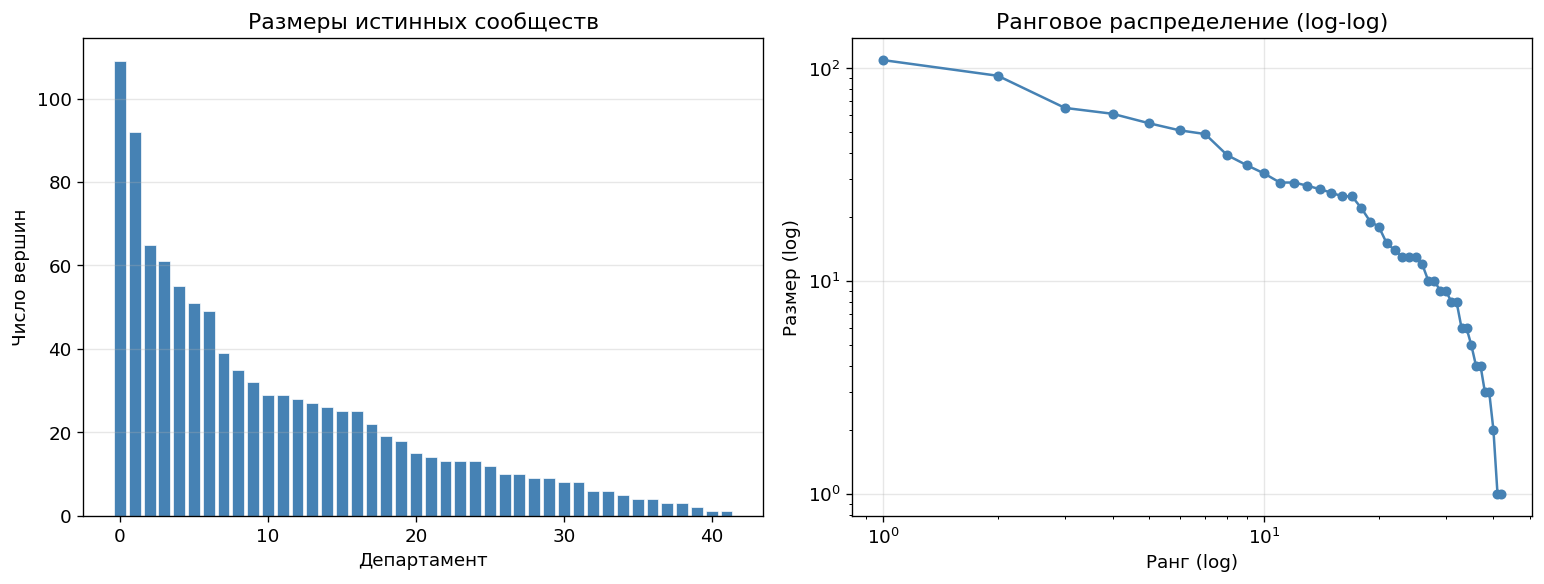

Наибольшее сообщество:     109 вершин  (10.8%)
Наименьшее сообщество:     1 вершин (0.10%)


In [9]:
dept_sizes = Counter(ground_truth.values())
sizes = sorted(dept_sizes.values(), reverse=True)
N = G.number_of_nodes()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(range(len(sizes)), sizes, color='steelblue', edgecolor='white', linewidth=0.4)
axes[0].set_xlabel('Департамент')
axes[0].set_ylabel('Число вершин')
axes[0].set_title('Размеры истинных сообществ')
axes[0].grid(axis='y', alpha=0.3)

axes[1].loglog(range(1, len(sizes)+1), sizes, 'o-', color='steelblue', markersize=5)
axes[1].set_xlabel('Ранг (log)')
axes[1].set_ylabel('Размер (log)')
axes[1].set_title('Ранговое распределение (log-log)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Наибольшее сообщество:     {sizes[0]} вершин  ({100*sizes[0]/N:.1f}%)')
print(f'Наименьшее сообщество:     {sizes[-1]} вершин ({100*sizes[-1]/N:.2f}%)')

Сеть содержит **42 департамента** с существенно неоднородным распределением размеров.
Наибольший департамент включает **>100 сотрудников ** от всей сети,
наименьший — всего **~0-1 сотрудника**.

## 2.2 Алгоритмы обнаружения сообществ

In [11]:
Gc = G.subgraph(max(nx.connected_components(G), key=len)).copy()
print(f'LCC: {Gc.number_of_nodes()} вершин, {Gc.number_of_edges()} рёбер')

nodes_gc = list(Gc.nodes())
y_true = np.array([ground_truth[n] for n in nodes_gc])
k_true = len(set(y_true))
print(f'Число истинных департаментов в LCC: {k_true}')

LCC: 986 вершин, 16687 рёбер
Число истинных департаментов в LCC: 42


### Алгоритм 1: Greedy Modularity (аналог Louvain)

In [12]:
comm_greedy = list(nx.community.greedy_modularity_communities(Gc))

partition_greedy = {}
for cid, comm in enumerate(comm_greedy):
    for node in comm:
        partition_greedy[node] = cid

y_greedy  = np.array([partition_greedy[n] for n in nodes_gc])
nmi_greedy = normalized_mutual_info_score(y_true, y_greedy)
q_greedy   = nx.community.modularity(Gc, comm_greedy)

print(f'  Кластеров: {len(comm_greedy)}')
print(f'  NMI = {nmi_greedy:.4f}')
print(f'  Q   = {q_greedy:.4f}')

  Кластеров: 25
  NMI = 0.4749
  Q   = 0.3655


### Алгоритм 2: Label Propagation

In [13]:
best_nmi_lp, best_comm_lp = -1, None
for seed in range(5):
    comm_lp_cur = list(nx.community.label_propagation_communities(Gc))
    part = {n: cid for cid, c in enumerate(comm_lp_cur) for n in c}
    y_cur = np.array([part[n] for n in nodes_gc])
    nmi_cur = normalized_mutual_info_score(y_true, y_cur)
    if nmi_cur > best_nmi_lp:
        best_nmi_lp  = nmi_cur
        best_comm_lp = comm_lp_cur
        y_lp = y_cur

nmi_lp = best_nmi_lp
q_lp   = nx.community.modularity(Gc, best_comm_lp)

print(f'  Кластеров: {len(best_comm_lp)}')
print(f'  NMI = {nmi_lp:.4f}')
print(f'  Q   = {q_lp:.4f}')

  Кластеров: 19
  NMI = 0.1593
  Q   = 0.0870


### Алгоритм 3: Async Fluid Communities

In [14]:
comm_fluid = list(nx.community.asyn_fluidc(Gc, k=k_true, seed=42))

partition_fluid = {n: cid for cid, c in enumerate(comm_fluid) for n in c}
y_fluid   = np.array([partition_fluid[n] for n in nodes_gc])
nmi_fluid = normalized_mutual_info_score(y_true, y_fluid)
q_fluid   = nx.community.modularity(Gc, comm_fluid)

print(f'  Кластеров: {len(comm_fluid)}')
print(f'  NMI = {nmi_fluid:.4f}')
print(f'  Q   = {q_fluid:.4f}')

  Кластеров: 42
  NMI = 0.6827
  Q   = 0.3023


## 2.2 Сравнение алгоритмов

In [17]:
results = {
    'Greedy Modularity': {'NMI': nmi_greedy, 'Q': q_greedy, 'k': len(comm_greedy)},
    'Label Propagation': {'NMI': nmi_lp,     'Q': q_lp,     'k': len(best_comm_lp)},
    'Async Fluid':       {'NMI': nmi_fluid,   'Q': q_fluid,  'k': len(comm_fluid)},
}
if leiden_available:
    results['Leiden'] = {'NMI': nmi_leiden, 'Q': q_leiden, 'k': n_leiden}

df = pd.DataFrame(results).T.sort_values('NMI', ascending=False)
df.index.name = 'Алгоритм'
df['k_true'] = k_true

print(df.round(4).to_string())

                      NMI       Q     k  k_true
Алгоритм                                       
Async Fluid        0.6827  0.3023  42.0      42
Greedy Modularity  0.4749  0.3655  25.0      42
Label Propagation  0.1593  0.0870  19.0      42


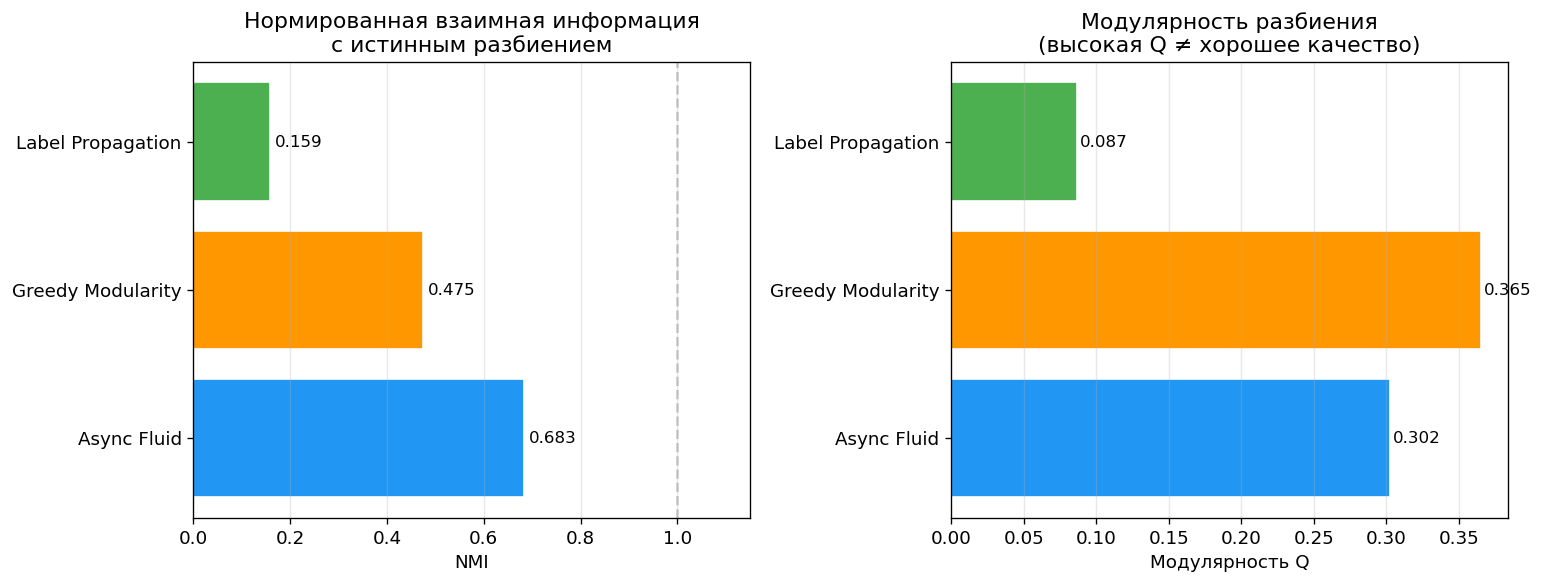

In [18]:
COLORS = ['#2196F3', '#FF9800', '#4CAF50', '#9C27B0']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
algo_names = list(df.index)
colors = COLORS[:len(algo_names)]

bars = axes[0].barh(algo_names, df['NMI'], color=colors, edgecolor='white')
axes[0].set_xlabel('NMI')
axes[0].set_title('Нормированная взаимная информация\nс истинным разбиением')
axes[0].set_xlim(0, 1.15)
axes[0].axvline(1.0, color='gray', linestyle='--', alpha=0.4)
axes[0].grid(axis='x', alpha=0.3)
for bar, val in zip(bars, df['NMI']):
    axes[0].text(val + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=10)

# Q
bars2 = axes[1].barh(algo_names, df['Q'], color=colors, edgecolor='white')
axes[1].set_xlabel('Модулярность Q')
axes[1].set_title('Модулярность разбиения\n(высокая Q ≠ хорошее качество)')
axes[1].grid(axis='x', alpha=0.3)
for bar, val in zip(bars2, df['Q']):
    axes[1].text(val + 0.002, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

Вывод

По метрике NMI (нормированная взаимная информация с истинным разбиением)
алгоритмы ранжируются следующим образом:

| Алгоритм          | NMI   | Q     |
|-------------------|-------|-------|
| Async Fluid       | 0.683 | 0.302 |
| Greedy Modularity | 0.475 | 0.365 |
| Label Propagation | 0.159 | 0.087 |

**Async Fluid** показывает наилучший результат по NMI (0.683), хотя
его модулярность Q = 0.302 — не максимальная.

**Greedy Modularity** имеет наибольшую модулярность Q = 0.365, хотя
NMI = 0.475 — заметно хуже Async Fluid. Алгоритм оптимизирует Q и находит разбиение,
"хорошее" с точки зрения модулярности, но не совпадающее с реальными
данными — маленькие сообщества сливаются в более крупные блоки.

**Label Propagation** показывает худший результат (NMI = 0.159,
Q = 0.087). Алгоритм стохастичен и не имеет механизма контроля
числа кластеров — в итоге он сходится к разбиению, плохо
согласующемуся с реальной структурой сети.


## 2.3 Точность обнаружения наибольшего и наименьшего кластера

In [19]:
def cluster_f1(y_pred, y_true, target_dept):

    mask_true = (y_true == target_dept)

    best_pred_label = Counter(y_pred[mask_true]).most_common(1)[0][0]

    y_t = mask_true.astype(int)
    y_p = (y_pred == best_pred_label).astype(int)

    tp = np.sum((y_p == 1) & (y_t == 1))
    precision = tp / (np.sum(y_p) + 1e-9)
    recall    = tp / (np.sum(y_t) + 1e-9)
    f1        = 2 * precision * recall / (precision + recall + 1e-9)
    return {'Precision': precision, 'Recall': recall, 'F1': f1}


dept_sizes_gc = Counter(ground_truth[n] for n in Gc.nodes() if n in ground_truth)
largest_dept  = dept_sizes_gc.most_common(1)[0][0]
smallest_dept = dept_sizes_gc.most_common()[-1][0]

print(f'Наибольший кластер:  департамент {largest_dept}  ({dept_sizes_gc[largest_dept]} вершин)')
print(f'Наименьший кластер:  департамент {smallest_dept} ({dept_sizes_gc[smallest_dept]} вершин)')

Наибольший кластер:  департамент 4  (107 вершин)
Наименьший кластер:  департамент 33 (1 вершин)


In [21]:
algo_preds = {
    'Greedy Modularity': y_greedy,
    'Label Propagation': y_lp,
    'Async Fluid':       y_fluid,
}
if leiden_available:
    algo_preds['Leiden'] = y_leiden

rows_large, rows_small = [], []
for name, y_pred in algo_preds.items():
    m_l = cluster_f1(y_pred, y_true, largest_dept)
    m_s = cluster_f1(y_pred, y_true, smallest_dept)
    rows_large.append({'Алгоритм': name, **m_l})
    rows_small.append({'Алгоритм': name, **m_s})

df_large = pd.DataFrame(rows_large).set_index('Алгоритм')
df_small = pd.DataFrame(rows_small).set_index('Алгоритм')

print(f'Наибольший кластер (деп. {largest_dept}, n={dept_sizes_gc[largest_dept]}) ===')
print(df_large.round(3).to_string())

print(f'Наименьший кластер (деп. {smallest_dept}, n={dept_sizes_gc[smallest_dept]}) ===')
print(df_small.round(3).to_string())

Наибольший кластер (деп. 4, n=107) ===
                   Precision  Recall     F1
Алгоритм                                   
Greedy Modularity      0.308   0.925  0.463
Label Propagation      0.119   0.991  0.212
Async Fluid            1.000   0.280  0.438
Наименьший кластер (деп. 33, n=1) ===
                   Precision  Recall     F1
Алгоритм                                   
Greedy Modularity      0.003     1.0  0.006
Label Propagation      0.001     1.0  0.002
Async Fluid            0.056     1.0  0.105


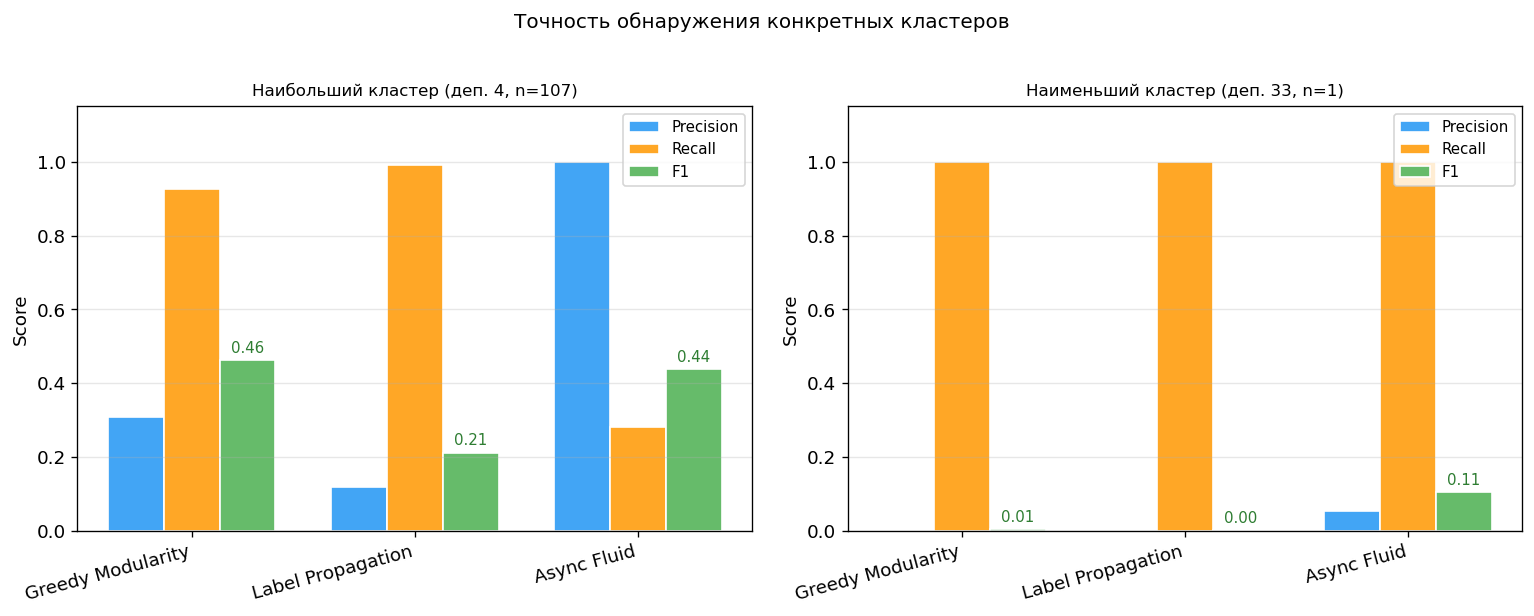

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
algo_names = list(algo_preds.keys())
x = np.arange(len(algo_names))
width = 0.25
colors_bar = COLORS[:len(algo_names)]

for ax, df_res, dept, title in [
    (axes[0], df_large, largest_dept,  f'Наибольший кластер (деп. {largest_dept}, n={dept_sizes_gc[largest_dept]})'),
    (axes[1], df_small, smallest_dept, f'Наименьший кластер (деп. {smallest_dept}, n={dept_sizes_gc[smallest_dept]})')
]:
    prec = df_res.loc[algo_names, 'Precision'].values
    rec  = df_res.loc[algo_names, 'Recall'].values
    f1   = df_res.loc[algo_names, 'F1'].values

    ax.bar(x - width, prec, width, label='Precision', color='#42A5F5', edgecolor='white')
    ax.bar(x,         rec,  width, label='Recall',    color='#FFA726', edgecolor='white')
    ax.bar(x + width, f1,   width, label='F1',        color='#66BB6A', edgecolor='white')

    ax.set_xticks(x)
    ax.set_xticklabels(algo_names, rotation=15, ha='right')
    ax.set_ylim(0, 1.15)
    ax.set_ylabel('Score')
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

    for i, v in enumerate(f1):
        ax.text(i + width, v + 0.02, f'{v:.2f}', ha='center', fontsize=9, color='#2E7D32')

plt.suptitle('Точность обнаружения конкретных кластеров', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

Вывод

Наибольший кластер (деп. 4, n=107)

Все алгоритмы в целом справляются — большой кластер сложно
не заметить. Лучший F1 у Greedy Modularity (0.46) и Async Fluid (0.44).
Но даже здесь результаты скромные: Greedy "раздувает" кластер
(Recall=0.92, Precision=0.31), Async Fluid наоборот — находит
чистое ядро, но упускает большую часть вершин (Precision=1.0,
Recall=0.28). Label Propagation хуже всех — F1=0.21.

Наименьший кластер (деп. 33, n=1

Все алгоритмы фактически не справляются. F1 близок к нулю у
Greedy и Label Propagation, у Async Fluid чуть лучше (F1=0.11)
за счёт того, что ему задали правильное k=42 и он вынужден
создавать маленькие кластеры.


Это классический resolution limit модулярности: алгоритмам
"невыгодно" выделять маленькие сообщества, проще слить их
с соседями и получить побольше модулярность. В нашем графе все 42
департамента меньше порога, поэтому
ни один не обнаруживается хорошо.

### Задача 3. SI модель в случайных сетях

In [37]:
N        = 10_000   # число вершин
K_AVG    = 10       # целевая средняя степень
BETA     = 0.05     # вероятность заражения за шаг,  начальный рост не мгновенный, подобран эмпирически
T_STEPS  = 60       # число шагов
N_RUNS   = 10       # число запусков для усреднения
I0_FRAC  = 0.01     # начальная доля заражённых

np.random.seed(42)

Генерируем 4 модели с одинаковым $N = 10^4$ и $\langle k \rangle \approx 10$:

In [36]:
# Эрдеш-Реньи
p_er = K_AVG / (N - 1)
G_er = nx.erdos_renyi_graph(N, p_er, seed=42)

# Барабаши-Альберт
m_ba = K_AVG // 2
G_ba = nx.barabasi_albert_graph(N, m_ba, seed=42)

# Уоттс-Строгатц
G_ws = nx.watts_strogatz_graph(N, K_AVG, p=0.1, seed=42)

# Геометрическая сеть 
r_rgg = np.sqrt(K_AVG / (np.pi * N))
G_rgg = nx.random_geometric_graph(N, r_rgg, seed=42)

graphs = {
    'Erdos-Renyi':        G_er,
    'Barabasi-Albert':    G_ba,
    'Watts-Strogatz':     G_ws,
    'Geometric (RGG)':    G_rgg,
}

print(f'{'Модель':25s} | {'N':>6} | {'E':>7} | {"<k>":>6} | {"<k²>":>8} |')
for name, G in graphs.items():
    degrees = [d for _, d in G.degree()]
    print(f'{name:25s} | {G.number_of_nodes():>6} | {G.number_of_edges():>7} |',
          f'{np.mean(degrees):>6.2f} | {np.mean(np.array(degrees)**2):>8.1f} |')

Модель                    |      N |       E |    <k> |     <k²> |
Erdos-Renyi               |  10000 |   49728 |   9.95 |    108.7 |
Barabasi-Albert           |  10000 |   49975 |   9.99 |    292.7 |
Watts-Strogatz            |  10000 |   50000 |  10.00 |    101.0 |
Geometric (RGG)           |  10000 |   49653 |   9.93 |    109.6 |


## SI симуляция

In [32]:
def run_si(G, beta, t_steps, i0_frac, seed=None):
    rng = np.random.default_rng(seed)
    nodes = list(G.nodes())
    n = len(nodes)

    n_infected = max(1, int(i0_frac * n))
    infected = set(rng.choice(nodes, size=n_infected, replace=False))

    history = [len(infected) / n]

    for _ in range(t_steps):
        new_infected = set()
        for node in infected:
            for nb in G.neighbors(node):
                if nb not in infected and rng.random() < beta:
                    new_infected.add(nb)
        infected |= new_infected
        history.append(len(infected) / n)

    return np.array(history)


def run_si_avg(G, beta, t_steps, i0_frac, n_runs):
    runs = [run_si(G, beta, t_steps, i0_frac, seed=s) for s in range(n_runs)]
    return np.mean(runs, axis=0)


def mean_field(t_arr, beta, k_avg, i0):
    exp_t = np.exp(beta * k_avg * t_arr)
    return (i0 * exp_t) / (1 - i0 + i0 * exp_t)

In [31]:
results = {}
for name, G in graphs.items():
    print(f'  {name}')
    results[name] = run_si_avg(G, BETA, T_STEPS, I0_FRAC, N_RUNS)


  Erdos-Renyi
  Barabasi-Albert
  Watts-Strogatz
  Geometric (RGG)


## Визуализация

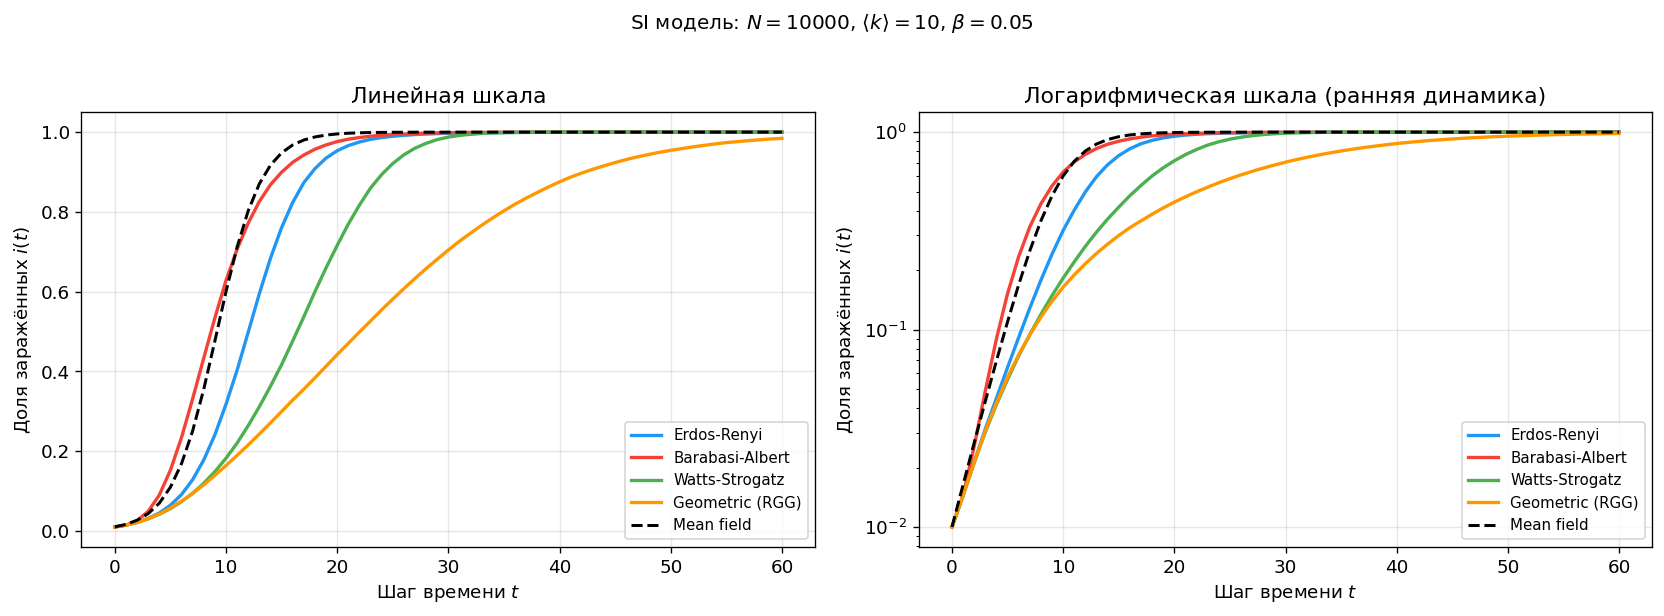

In [28]:
t_arr = np.arange(T_STEPS + 1)
i_mf  = mean_field(t_arr, BETA, K_AVG, I0_FRAC)

colors = {
    'Erdos-Renyi':      '#2196F3',
    'Barabasi-Albert':  '#F44336',
    'Watts-Strogatz':   '#4CAF50',
    'Geometric (RGG)':  '#FF9800',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax in axes:
    for name, curve in results.items():
        ax.plot(t_arr, curve, color=colors[name], label=name, linewidth=2)
    ax.plot(t_arr, i_mf, 'k--', linewidth=1.8, label='Mean field')
    ax.set_xlabel('Шаг времени $t$')
    ax.set_ylabel('Доля заражённых $i(t)$')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9)

axes[0].set_title('Линейная шкала')
axes[1].set_yscale('log')
axes[1].set_title('Логарифмическая шкала (ранняя динамика)')

plt.suptitle(f'SI модель: $N={N}$, $\\langle k \\rangle={K_AVG}$, $\\beta={BETA}$',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

Все сети имеют одинаковые N и k, но инфекция распространяется
совершенно по-разному 

**BA (красный) — быстрее всех.**
Всё из-за хабов: пара вершин со степенью 100+ заражается в первые
шаги и мгновенно разносит вирус по всей сети

**ER (синий) идёт почти вплотную с mean field (пунктир).**
mean field как раз и предполагает однородную сеть
без какой-либо структуры, что близко к ER. Небольшое отставание
есть, но незначительное.

**WS (зелёный) заметно медленнее ER.**
Виновата высокая кластеризация: соседи заражённого сами уже
заражены, новых жертв вокруг почти нет. Инфекция "топчется"
на месте

**RGG (оранжевый) — отстаёт от всех почти вдвое.**
Никаких хабов, никаких длинных рёбер

**На логарифмическом графике** видно, что в самом начале (t<5) все кривые идут очти одинаково.
Потом они расходятся

# Задача 4. SIR модель на сетях различной структуры

In [38]:
G1 = nx.read_graphml('graph1.graphml')
G2 = nx.read_graphml('graph2.graphml')

# Убеждаемся что графы ненаправленные
if G1.is_directed():
    G1 = G1.to_undirected()
if G2.is_directed():
    G2 = G2.to_undirected()

print(f'G1: {G1.number_of_nodes()} вершин, {G1.number_of_edges()} рёбер')
print(f'G2: {G2.number_of_nodes()} вершин, {G2.number_of_edges()} рёбер')

G1: 750 вершин, 22435 рёбер
G2: 750 вершин, 22435 рёбер


In [40]:
beta               = 0.005
gamma              = 0.03
percentage_infected = 0.002
n_iter             = 200
n_run              = 100

R0_approx = beta / gamma
print(f'β = {beta},  γ = {gamma}')
print(f'β/γ = {R0_approx:.3f}')

β = 0.005,  γ = 0.03
β/γ = 0.167


## Исследование топологии G1 и G2


In [50]:
def topology_report(G, name):
    degrees = np.array([d for _, d in G.degree()])
    k_avg   = degrees.mean()
    k2_avg  = (degrees**2).mean()
    k_max   = degrees.max()
    k_min   = degrees.min()
    R0_het  = (beta / gamma) * k2_avg / k_avg

    # Связность
    n_comp  = nx.number_connected_components(G)
    lcc     = len(max(nx.connected_components(G), key=len))

    Gc = G.subgraph(max(nx.connected_components(G), key=len))
    clust   = nx.average_clustering(Gc)
 
    print(f'{name}')
    print(f'  Связных компонент:    {n_comp}')
    print(f'  Размер LCC:           {lcc} ({100*lcc/G.number_of_nodes():.1f}%)')
    print(f'  <k>:                  {k_avg:.2f}')
    print(f'  <k²>/<k>:             {k2_avg/k_avg:.2f}')
    print(f'  k_max:                {k_max}')
    print(f'  k_min:                {k_min}')
    print(f'  Clustering:           {clust:.4f}')
    print(f'  R0:                   {R0_het:.3f} - {"эпидемия" if R0_het > 1 else "затухание"}')
    return degrees


In [51]:
deg1 = topology_report(G1, 'G1')
deg2 = topology_report(G2, 'G2')

G1
  Связных компонент:    1
  Размер LCC:           750 (100.0%)
  <k>:                  59.83
  <k²>/<k>:             60.71
  k_max:                82
  k_min:                39
  Clustering:           0.7120
  R0:                   10.119 - эпидемия
G2
  Связных компонент:    1
  Размер LCC:           750 (100.0%)
  <k>:                  59.83
  <k²>/<k>:             60.71
  k_max:                82
  k_min:                39
  Clustering:           0.0799
  R0:                   10.119 - эпидемия


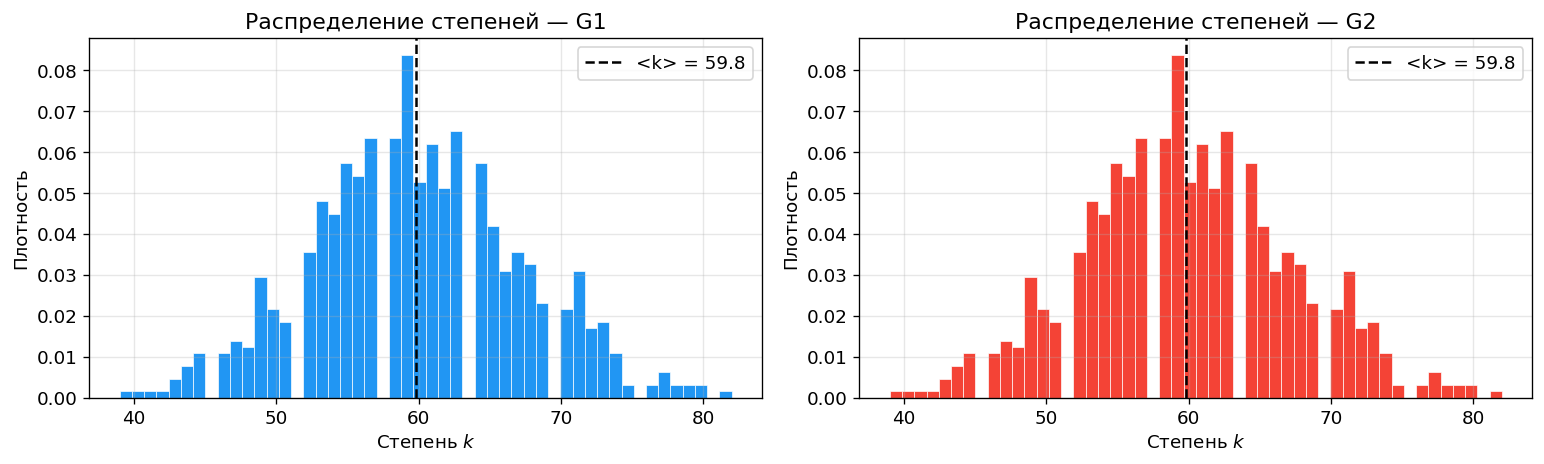

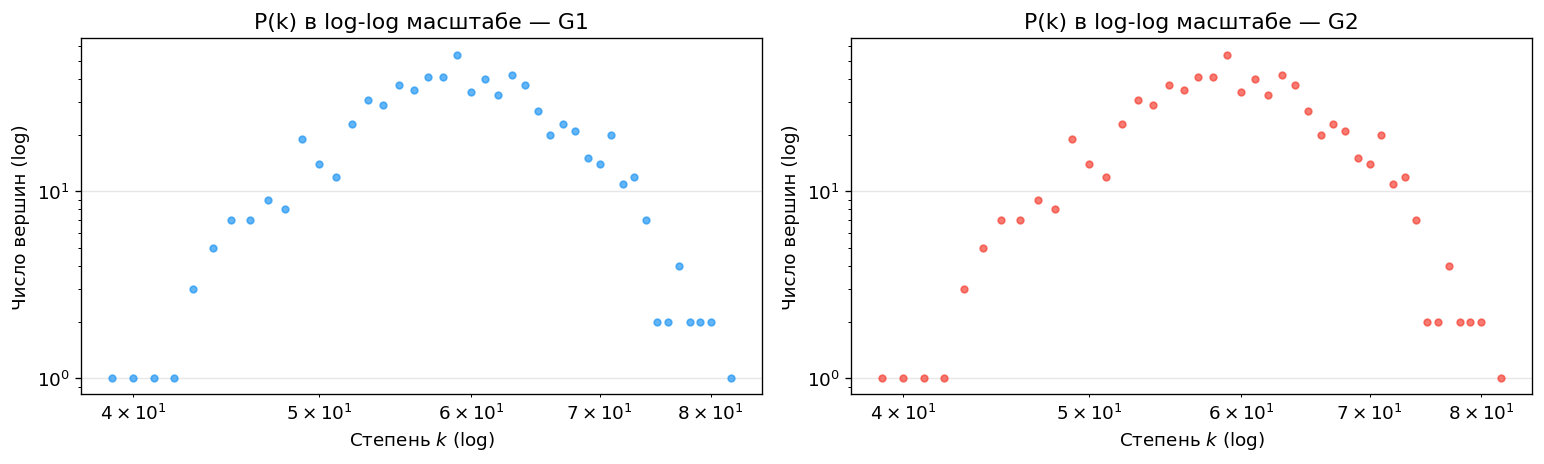

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, degrees, name, color in [
    (axes[0], deg1, 'G1', '#2196F3'),
    (axes[1], deg2, 'G2', '#F44336'),
]:
    ax.hist(degrees, bins=50, color=color, edgecolor='white',
            linewidth=0.4, density=True)
    ax.axvline(degrees.mean(), color='black', linestyle='--',
               linewidth=1.5, label=f'<k> = {degrees.mean():.1f}')
    ax.set_xlabel('Степень $k$')
    ax.set_ylabel('Плотность')
    ax.set_title(f'Распределение степеней — {name}')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, degrees, name, color in [
    (axes[0], deg1, 'G1', '#2196F3'),
    (axes[1], deg2, 'G2', '#F44336'),
]:
    counts = np.bincount(degrees)
    k_vals = np.where(counts > 0)[0]
    ax.loglog(k_vals, counts[k_vals], 'o', color=color, markersize=4, alpha=0.7)
    ax.set_xlabel('Степень $k$ (log)')
    ax.set_ylabel('Число вершин (log)')
    ax.set_title(f'P(k) в log-log масштабе — {name}')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

G1 и G2 имеют практически одинаковое распределение степеней:
<k> = 59.8, диапазон от 40 до 85, форма близка к нормальной —
хабов нет, сеть однородная. В log-log прямой линии нет,
значит степенного закона тоже нет. Если SIR-кривые всё же
отличатся — дело не в степенях, а в другой структуре графов.

## SIR симуляция

In [53]:
def run_sir(G, beta, gamma, perc_infected, n_iter, seed=None):
    rng   = np.random.default_rng(seed)
    nodes = list(G.nodes())
    n     = len(nodes)

    n_infected = max(1, int(perc_infected * n))
    infected   = set(rng.choice(nodes, size=n_infected, replace=False))
    recovered  = set()

    S_arr, I_arr, R_arr = [], [], []

    for _ in range(n_iter):
        susceptible = set(nodes) - infected - recovered
        S_arr.append(len(susceptible) / n)
        I_arr.append(len(infected)   / n)
        R_arr.append(len(recovered)  / n)

        # Новые заражения
        new_infected = set()
        for node in infected:
            for nb in G.neighbors(node):
                if nb in susceptible and rng.random() < beta:
                    new_infected.add(nb)

        new_recovered = {node for node in infected if rng.random() < gamma}

        infected  = (infected | new_infected) - new_recovered
        recovered = recovered | new_recovered

        if len(infected) == 0:
            remaining = n_iter - len(S_arr)
            S_arr += [len(susceptible - new_infected) / n] * remaining
            I_arr += [0.0] * remaining
            R_arr += [(len(recovered) + len(new_recovered)) / n] * remaining
            break

    return np.array(S_arr), np.array(I_arr), np.array(R_arr)


def run_sir_avg(G, beta, gamma, perc_infected, n_iter, n_run):
    S_list, I_list, R_list = [], [], []
    for seed in range(n_run):
        S, I, R = run_sir(G, beta, gamma, perc_infected, n_iter, seed=seed)
        S_list.append(S)
        I_list.append(I)
        R_list.append(R)
    return (np.mean(S_list, axis=0),
            np.mean(I_list, axis=0),
            np.mean(R_list, axis=0))

In [55]:
S1, I1, R1 = run_sir_avg(G1, beta, gamma, percentage_infected, n_iter, n_run)
S2, I2, R2 = run_sir_avg(G2, beta, gamma, percentage_infected, n_iter, n_run)

## Визуализация SIR кривых

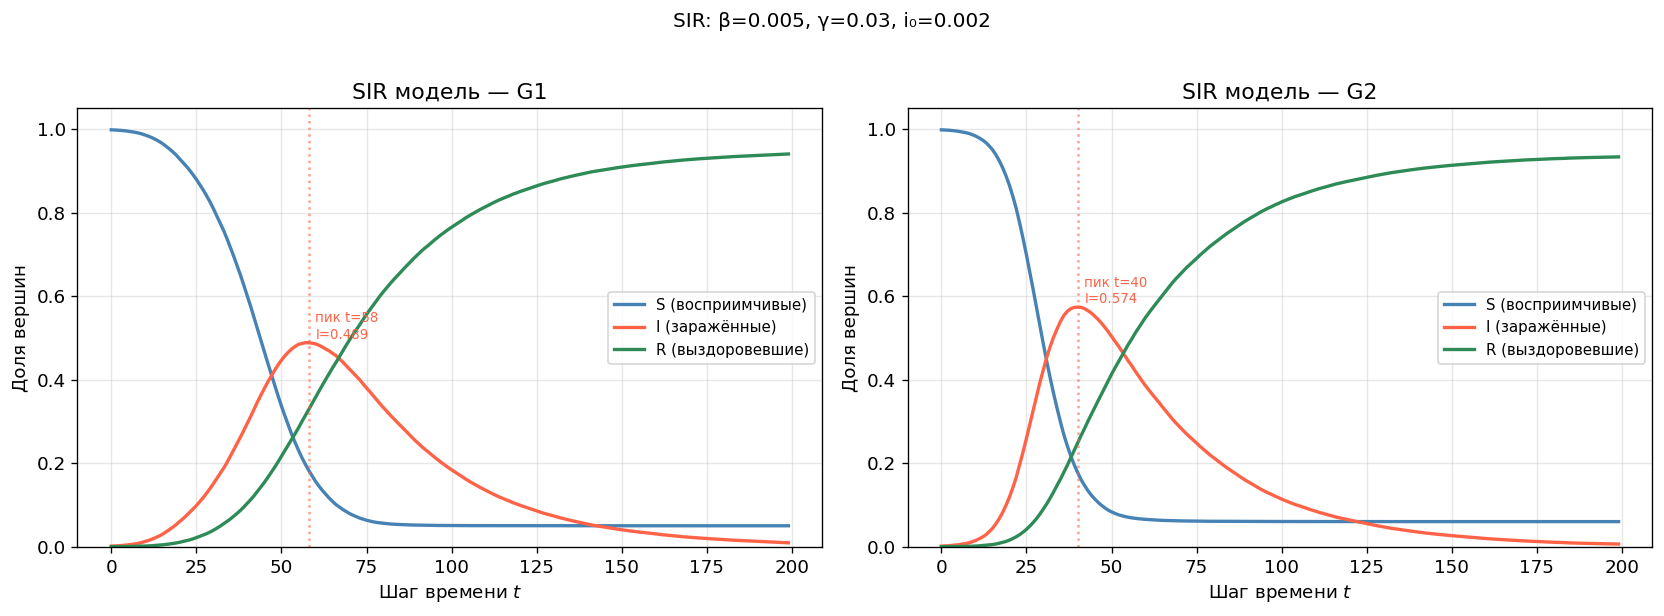

  G1: 0.9408 (94.1%)
  G2: 0.9338 (93.4%)


In [57]:
t = np.arange(n_iter)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (S, I, R), name, c_main in [
    (axes[0], (S1, I1, R1), 'G1', '#2196F3'),
    (axes[1], (S2, I2, R2), 'G2', '#F44336'),
]:
    ax.plot(t, S, color='steelblue',  linewidth=2,   label='S (восприимчивые)')
    ax.plot(t, I, color='tomato',     linewidth=2,   label='I (заражённые)')
    ax.plot(t, R, color='seagreen',   linewidth=2,   label='R (выздоровевшие)')
    ax.set_xlabel('Шаг времени $t$')
    ax.set_ylabel('Доля вершин')
    ax.set_title(f'SIR модель — {name}')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_ylim(0, 1.05)

    # Отметим пик инфекции
    t_peak = np.argmax(I)
    ax.axvline(t_peak, color='tomato', linestyle=':', alpha=0.6)
    ax.text(t_peak + 2, I[t_peak] + 0.01,
            f'пик t={t_peak}\nI={I[t_peak]:.3f}',
            color='tomato', fontsize=8)

plt.suptitle(f'SIR: β={beta}, γ={gamma}, i₀={percentage_infected}',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print(f'  G1: {R1[-1]:.4f} ({100*R1[-1]:.1f}%)')
print(f'  G2: {R2[-1]:.4f} ({100*R2[-1]:.1f}%)')

Оба графа дают полноценную эпидемию (~94% переболевших),
но G2 распространяет инфекцию заметно быстрее: пик в t2 < t1
против G1, и пиковая доля заражённых выше.
Итог почти одинаковый — топология влияет на скорость,
но не на финальный масштаб при таком высоком R0.

## Сравнение G1 и G2 на одном графике

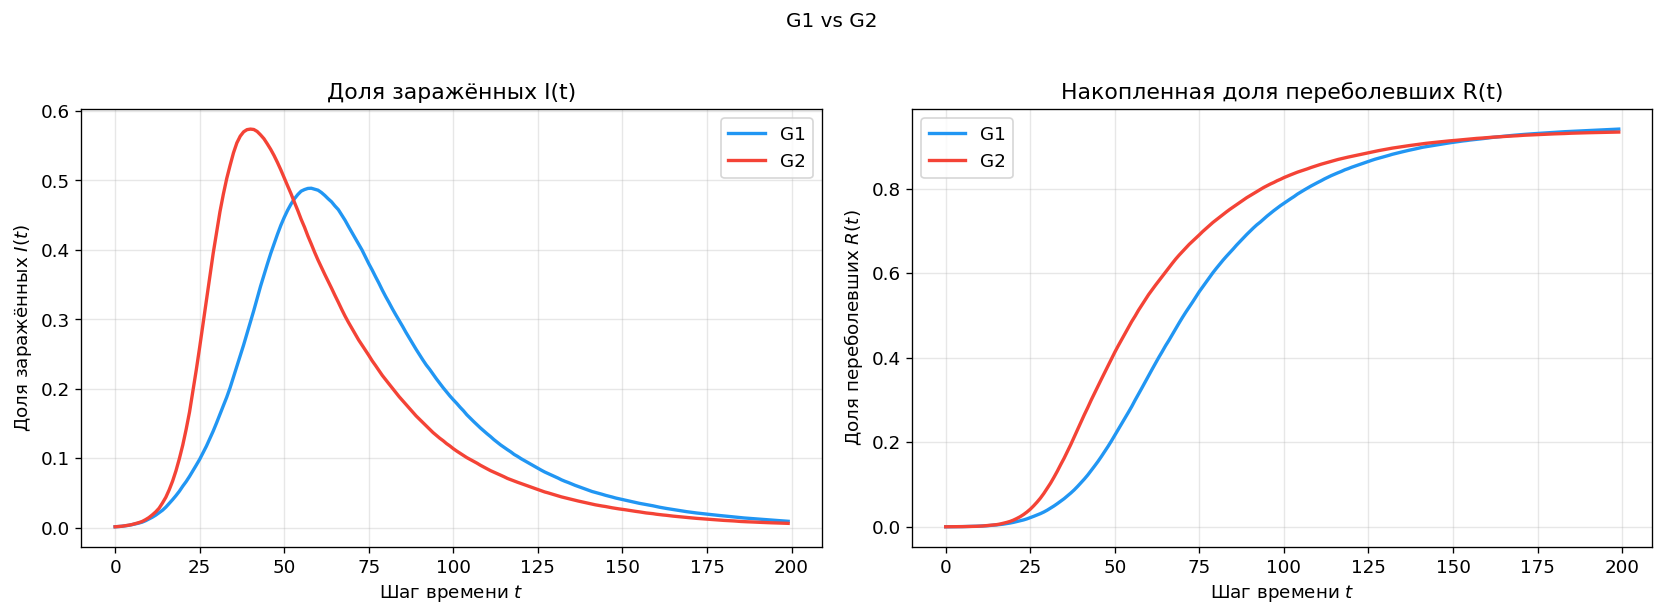

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(t, I1, color='#2196F3', linewidth=2, label='G1')
axes[0].plot(t, I2, color='#F44336', linewidth=2, label='G2')
axes[0].set_xlabel('Шаг времени $t$')
axes[0].set_ylabel('Доля заражённых $I(t)$')
axes[0].set_title('Доля заражённых I(t)')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(t, R1, color='#2196F3', linewidth=2, label='G1')
axes[1].plot(t, R2, color='#F44336', linewidth=2, label='G2')
axes[1].set_xlabel('Шаг времени $t$')
axes[1].set_ylabel('Доля переболевших $R(t)$')
axes[1].set_title('Накопленная доля переболевших R(t)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('G1 vs G2', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

G2 (красный) растет быстрее и резче — пик выше и наступает
раньше, что хорошо видно на левом графике. На правом графике
кривые сходятся к одному значению ~94% — финальный масштаб
эпидемии одинаковый, просто G2 добирается до него быстрее.

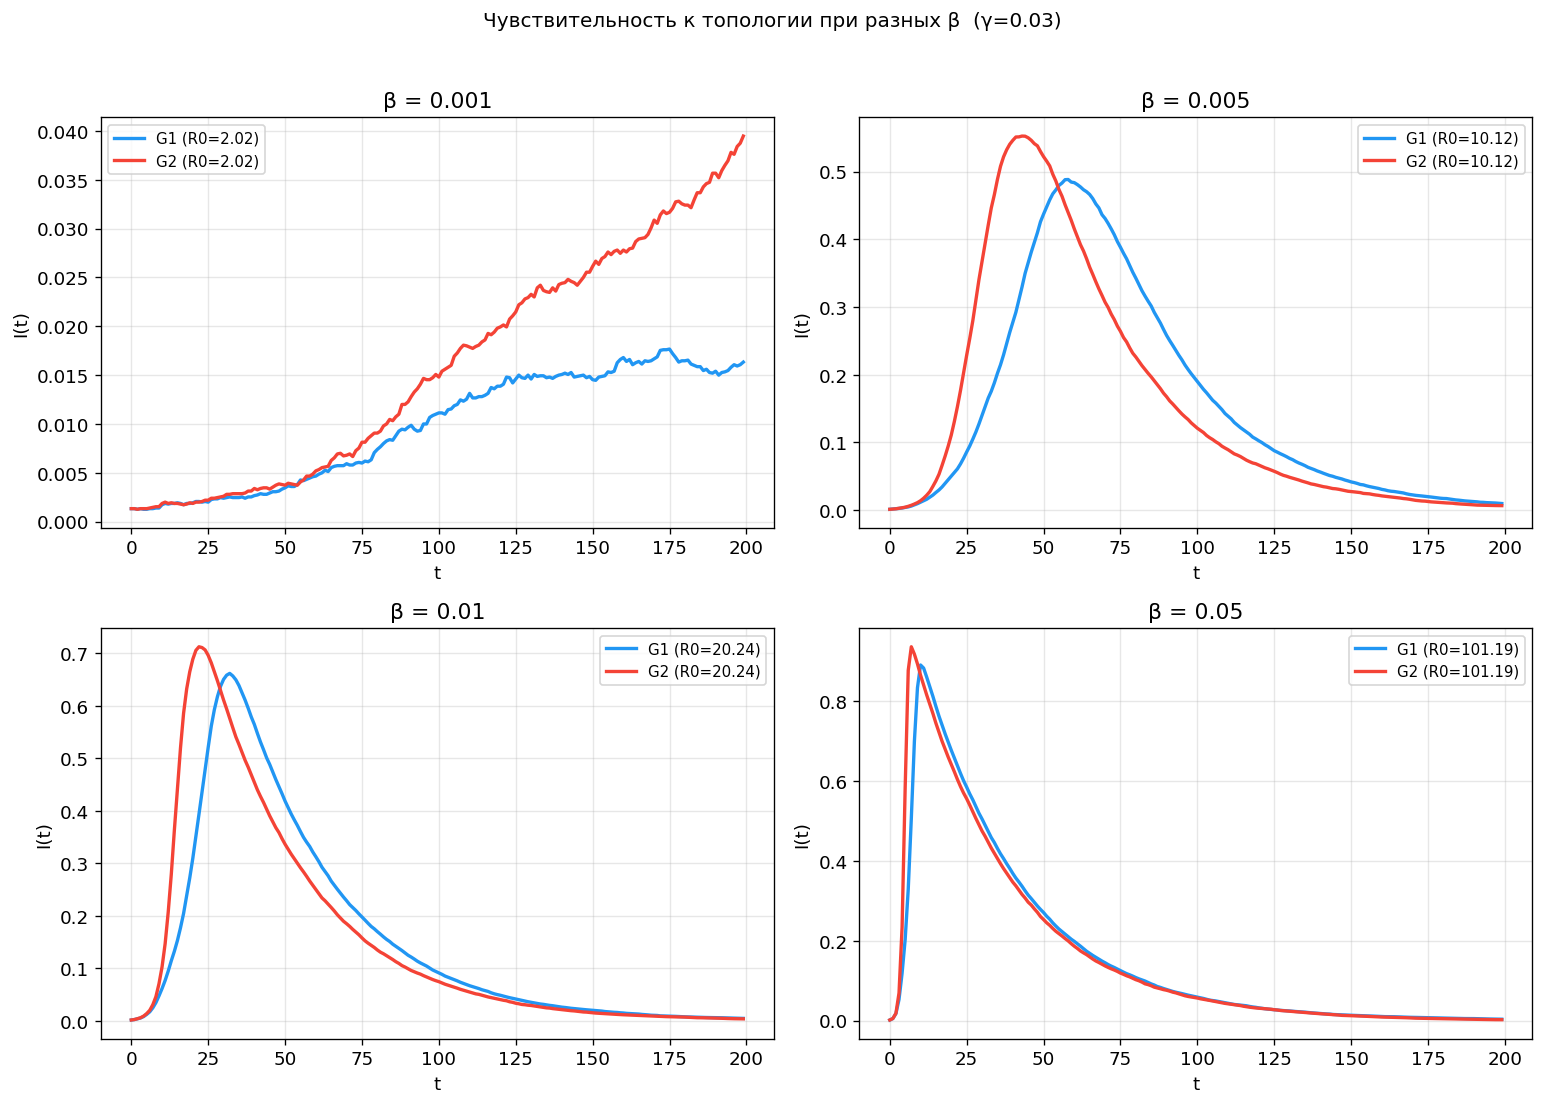

In [59]:
# Проверяем разные beta при фиксированном gamma
beta_values = [0.001, 0.005, 0.01, 0.05]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for ax, b in zip(axes, beta_values):
    R0_g1 = (b / gamma) * (deg1**2).mean() / deg1.mean()
    R0_g2 = (b / gamma) * (deg2**2).mean() / deg2.mean()

    _, I1b, R1b = run_sir_avg(G1, b, gamma, percentage_infected, n_iter, n_run=20)
    _, I2b, R2b = run_sir_avg(G2, b, gamma, percentage_infected, n_iter, n_run=20)

    ax.plot(t, I1b, color='#2196F3', linewidth=2, label=f'G1 (R0={R0_g1:.2f})')
    ax.plot(t, I2b, color='#F44336', linewidth=2, label=f'G2 (R0={R0_g2:.2f})')
    ax.set_title(f'β = {b}')
    ax.set_xlabel('t')
    ax.set_ylabel('I(t)')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle(f'Чувствительность к топологии при разных β  (γ={gamma})',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

При малом β=0.001 разница между G1 и G2 максимальна — G2
распространяет инфекцию заметно быстрее, кривые далеко друг
от друга. По мере роста β разрыв сокращается, и при β=0.05
кривые практически сливаются — при таком агрессивном заражении
топология уже не играет роли. Чувствительность к структуре
сети максимальна вблизи порога эпидемии.